# Convolutional Neural Networks para trabajar con CIFAR-10



## 1. Dataset CIFAR-10 y tarea asociada

**CIFAR-10** es un conjunto de datos de clasificación de imágenes a color con **60,000** imágenes de tamaño **32×32** píxeles, **3 canales (RGB)** y **10 clases**.

- Entrenamiento: **50,000**
- Prueba (test): **10,000**

### Clases
1. airplane
2. automobile
3. bird
4. cat
5. deer
6. dog
7. frog
8. horse
9. ship
10. truck

### Tarea
Dada una imagen RGB de 32×32, el modelo debe predecir su **etiqueta de clase** (clasificación multiclase).


## 2. Objetivo de la práctica

Esta práctica busca **probar el desempeño de las CNN** y analizar sus **fortalezas y debilidades** al trabajar con imágenes.

### Fortalezas típicas de CNN (para imágenes)
- Explotan **localidad espacial**: patrones como bordes/texturas se detectan con filtros pequeños (p.ej. 3×3).
- **Compartición de pesos**: un mismo filtro se aplica a toda la imagen → menos parámetros y mejor generalización.
- Construyen representaciones **jerárquicas**: bordes → texturas → partes → objetos.
- Mayor **robustez a traslaciones** pequeñas y variaciones locales (especialmente con pooling/strides).

### Debilidades / limitaciones
- Si se destruye la estructura espacial, las convoluciones dejan de ser informativas.
- Requieren decisiones de diseño: profundidad, ancho, normalización, regularización, etc.
- Pueden sobreajustar si son muy grandes o si el entrenamiento no está bien regulado.


In [1]:
import torch
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim

import math

SEED = 42
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

## 3. Obtener CIFAR-10 

In [2]:
# Normalización típica CIFAR-10 (RGB)
cifar10_mean = (0.4914, 0.4822, 0.4465)
cifar10_std  = (0.2470, 0.2435, 0.2616)

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(cifar10_mean, cifar10_std)
])

train_full = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_set = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

class_names = train_full.classes
len(train_full), len(test_set), class_names


(50000,
 10000,
 ['airplane',
  'automobile',
  'bird',
  'cat',
  'deer',
  'dog',
  'frog',
  'horse',
  'ship',
  'truck'])

## 4. Visualización: matriz de imágenes (2 por clase)


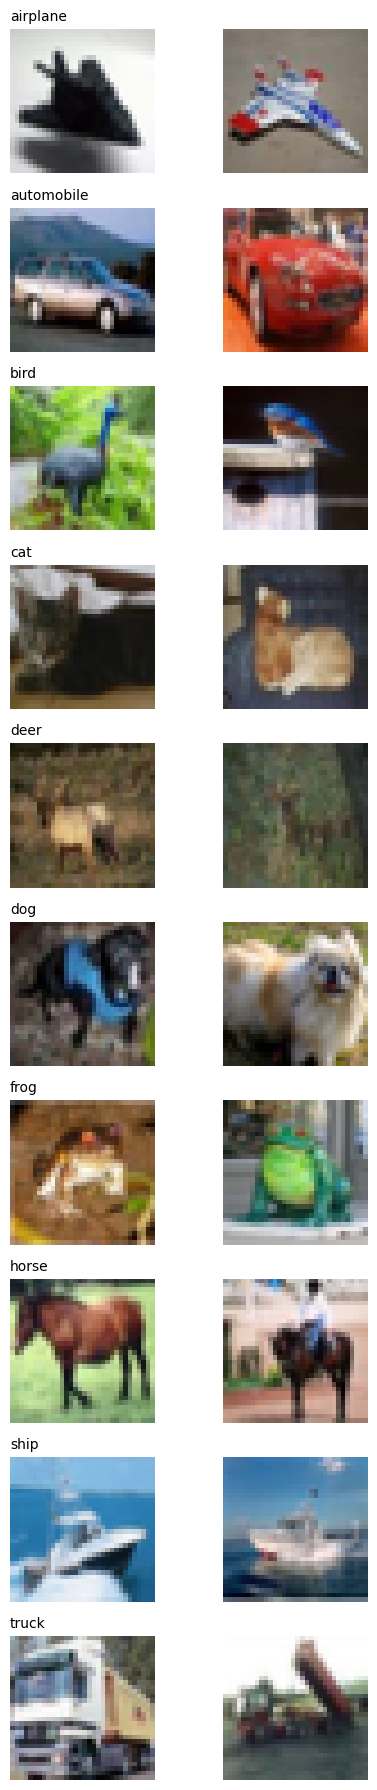

In [3]:
# Des-normalizar solo para visualizar
mean = torch.tensor(cifar10_mean).view(3,1,1)
std  = torch.tensor(cifar10_std).view(3,1,1)

def denormalize(img_tensor):
    return (img_tensor * std + mean).clamp(0, 1)

# Tomar 2 ejemplos por clase
examples = {c: [] for c in range(10)}
for img, label in train_full:
    if len(examples[label]) < 2:
        examples[label].append(img)
    if all(len(examples[c]) == 2 for c in range(10)):
        break

fig, axes = plt.subplots(10, 2, figsize=(5, 18))
for c in range(10):
    for j in range(2):
        ax = axes[c, j]
        img = denormalize(examples[c][j])
        ax.imshow(img.permute(1,2,0))
        ax.axis("off")
        if j == 0:
            ax.set_title(class_names[c], loc="left", fontsize=10)

plt.tight_layout()
plt.show()


## 5. Antecedente: copia "flat" para redes Fully-Connected (MLP)

Para MLP, convertimos cada imagen de (3,32,32) a un vector (3072).


In [4]:
x0, y0 = train_full[0]
print("Original:", x0.shape)
print("Flat:", torch.flatten(x0).shape)


Original: torch.Size([3, 32, 32])
Flat: torch.Size([3072])


### Wrapper para dataset "flat"

Este wrapper conserva el mismo dataset base, pero devuelve `x` aplanado.


In [5]:
class FlatWrapper(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]               # x: (3,32,32)
        x = torch.flatten(x, start_dim=0)   # x: (3072)
        return x, y

flat_train_full = FlatWrapper(train_full)
flat_test_set = FlatWrapper(test_set)

xf, yf = flat_train_full[0]
print("Flat sample shape:", xf.shape, "label:", yf)


Flat sample shape: torch.Size([3072]) label: 6


## 6. Partición entrenamiento/validación (10%) para original y flat 
Creamos una sola partición de índices y la aplicamos a ambos datasets.


In [6]:
val_fraction = 0.10
n_total = len(train_full)
n_val = int(n_total * val_fraction)
n_train = n_total - n_val

g = torch.Generator().manual_seed(SEED)
perm = torch.randperm(n_total, generator=g).tolist()

train_idx = perm[:n_train]
val_idx = perm[n_train:]

# Subsets ORIGINAL
train_set = Subset(train_full, train_idx)
val_set   = Subset(train_full, val_idx)

# Subsets FLAT (misma partición)
flat_train_set = Subset(flat_train_full, train_idx)
flat_val_set   = Subset(flat_train_full, val_idx)

print("Original train/val:", len(train_set), len(val_set))
print("Flat train/val:", len(flat_train_set), len(flat_val_set))


Original train/val: 45000 5000
Flat train/val: 45000 5000


In [7]:
BATCH_SIZE = 256
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

NUM_WORKERS = 0  # Evita cuelgues en Jupyter/Windows
PIN_MEMORY = True if DEVICE == "cuda" else False

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

val_loader   = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

flat_train_loader = DataLoader(flat_train_set, batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

flat_val_loader   = DataLoader(flat_val_set, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

flat_test_loader  = DataLoader(flat_test_set, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

xb, yb = next(iter(train_loader))
xfb, yfb = next(iter(flat_train_loader))

print("Batch original:", xb.shape, yb.shape)
print("Batch flat:", xfb.shape, yfb.shape)


Batch original: torch.Size([256, 3, 32, 32]) torch.Size([256])
Batch flat: torch.Size([256, 3072]) torch.Size([256])


## 7. Actividad: MLP (tu propuesta) + 5 topologías CNN + 1 CNN propuesta (SIN código)

### Instrucción A — MLP
Usa tu MLP de la práctica anterior y entrénalo con:
- `flat_train_loader`, `flat_val_loader`, `flat_test_loader`


In [8]:
class OptimizedMLP(nn.Module):
    def __init__(self, input_size=3072, output_size=10, l2_lambda=1e-4):
        super(OptimizedMLP, self).__init__()
        
        self.l2_lambda = l2_lambda
        
        self.model = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.ReLU(),               
            
            nn.Linear(1024, 512),
            nn.ReLU(),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            
            nn.Linear(256, output_size)
        )
        
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def compute_l2_penalty(self):
        l2_penalty = 0.0
        for name, param in self.named_parameters():
            if 'weight' in name:
                l2_penalty += torch.sum(param ** 2)
                
        return self.l2_lambda * l2_penalty

    def get_total_loss(self, outputs, targets):
        base_loss = self.criterion(outputs, targets)
        l2_loss = self.compute_l2_penalty()
        
        return base_loss + l2_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_opt = OptimizedMLP(l2_lambda=1e-4).to(device)

optimizer = optim.Adam(model_opt.parameters(), lr=1e-3, weight_decay=0)


Iniciando el entrenamiento...
Época [1/30] | Train Loss: 2.0221 - Train Acc: 0.3911 | Val Loss: 1.6011 - Val Acc: 0.4336
Época [2/30] | Train Loss: 1.7631 - Train Acc: 0.4565 | Val Loss: 1.5086 - Val Acc: 0.4650
Época [3/30] | Train Loss: 1.6837 - Train Acc: 0.4766 | Val Loss: 1.4927 - Val Acc: 0.4780
Época [4/30] | Train Loss: 1.6374 - Train Acc: 0.4930 | Val Loss: 1.4706 - Val Acc: 0.4806
Época [5/30] | Train Loss: 1.5790 - Train Acc: 0.5141 | Val Loss: 1.4735 - Val Acc: 0.4804
Época [6/30] | Train Loss: 1.5542 - Train Acc: 0.5234 | Val Loss: 1.4081 - Val Acc: 0.4984
Época [7/30] | Train Loss: 1.5285 - Train Acc: 0.5367 | Val Loss: 1.3768 - Val Acc: 0.5186
Época [8/30] | Train Loss: 1.5013 - Train Acc: 0.5483 | Val Loss: 1.3633 - Val Acc: 0.5158
Época [9/30] | Train Loss: 1.4830 - Train Acc: 0.5554 | Val Loss: 1.3606 - Val Acc: 0.5214
Época [10/30] | Train Loss: 1.4651 - Train Acc: 0.5669 | Val Loss: 1.3609 - Val Acc: 0.5196
Época [11/30] | Train Loss: 1.4540 - Train Acc: 0.5735 | Va

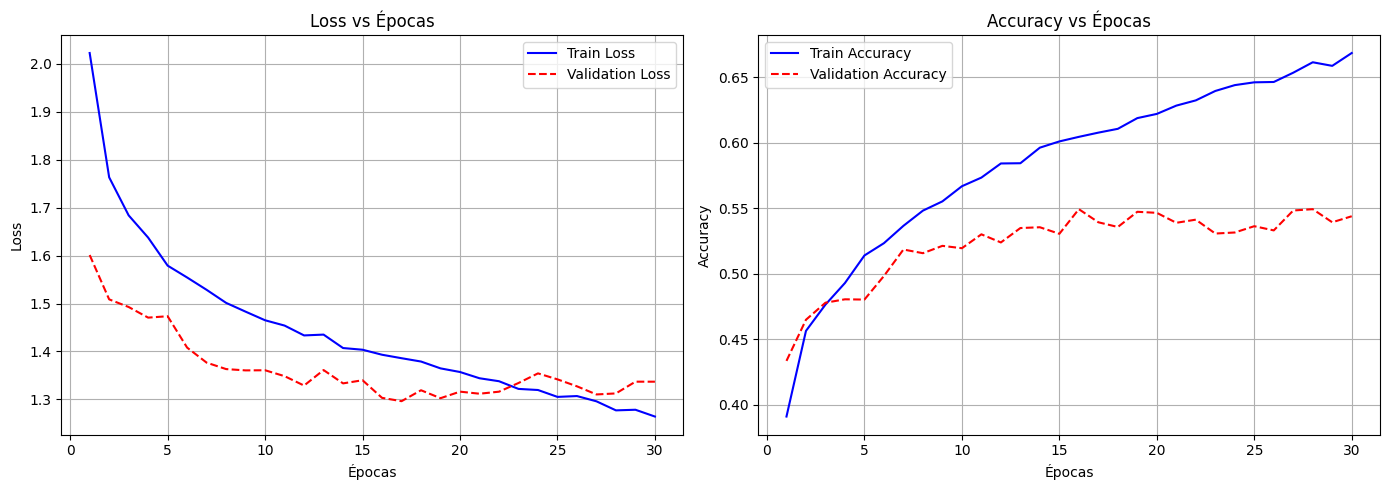

In [9]:
EPOCHS = 30
model_opt = OptimizedMLP(l2_lambda=1e-3).to(device)
optimizer = optim.AdamW(model_opt.parameters(), lr=1e-3, weight_decay=1e-4)

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("Iniciando el entrenamiento...")

for epoch in range(EPOCHS):
    model_opt.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in flat_train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model_opt(inputs)
        
        loss = model_opt.get_total_loss(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_train += torch.sum(preds == labels.data).item()
        total_train += labels.size(0)
        
    epoch_train_loss = running_train_loss / len(flat_train_loader.dataset)
    epoch_train_acc = correct_train / total_train
    
    train_losses.append(epoch_train_loss)
    train_accs.append(epoch_train_acc)

    model_opt.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for inputs, labels in flat_val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model_opt(inputs)
            loss = model_opt.criterion(outputs, labels) 
            
            running_val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct_val += torch.sum(preds == labels.data).item()
            total_val += labels.size(0)
            
    epoch_val_loss = running_val_loss / len(flat_val_loader.dataset)
    epoch_val_acc = correct_val / total_val
    
    val_losses.append(epoch_val_loss)
    val_accs.append(epoch_val_acc)
    
    print(f"Época [{epoch+1}/{EPOCHS}] | "
          f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} - Val Acc: {epoch_val_acc:.4f}")

print("\n¡Entrenamiento finalizado!")

model_opt.eval()
running_test_loss = 0.0
correct_test = 0
total_test = 0

with torch.no_grad():
    for inputs, labels in flat_test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model_opt(inputs)
        
        loss = model_opt.criterion(outputs, labels)
        
        running_test_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct_test += torch.sum(preds == labels.data).item()
        total_test += labels.size(0)

test_loss = running_test_loss / len(flat_test_loader.dataset)
test_acc = correct_test / total_test

print("-" * 40)
print(f"RESULTADOS FINALES EN TEST:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({(test_acc*100):.2f}%)")
print("-" * 40)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS+1), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, EPOCHS+1), val_losses, label='Validation Loss', color='red', linestyle='--')
plt.title('Loss vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS+1), train_accs, label='Train Accuracy', color='blue')
plt.plot(range(1, EPOCHS+1), val_accs, label='Validation Accuracy', color='red', linestyle='--')
plt.title('Accuracy vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Instrucción B — 5 CNN propuestas
Implementa y entrena las siguientes topologías usando:
- `train_loader`, `val_loader`, `test_loader`

**Hiperparámetros sugeridos (base):**
- Épocas: 30 
- Optimizador: AdamW
- LR: 1e-3
- Weight decay: 1e-4
- Loss: CrossEntropyLoss
- Batch size: 256
- Activación: ReLU
- Regularización: Dropout y/o BatchNorm

# Descripción detallada de las arquitecturas CNN propuestas

En todos los casos la entrada es una imagen de **CIFAR-10** con dimensión:

\[
(3, 32, 32)
\]

donde:
- 3 = canales RGB  
- 32×32 = resolución espacial  


In [10]:
EPOCAS = 30 
LEARNING_RATE= 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE = 256

In [11]:
class EntrenadorModelos:
    def __init__(self, model, train_loader, val_loader, test_loader, device='cuda'):
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader  
        self.test_loader = test_loader 
        self.device = device
        
        self.epochs = EPOCAS
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.AdamW(self.model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
        self.history = {
            'train_loss': [], 'train_acc': [],
            'val_loss': [], 'val_acc': []
        }
        
    def count_parameters(self):
        return sum(p.numel() for p in self.model.parameters() if p.requires_grad)

    def _calculate_accuracy(self, outputs, labels):
        _, preds = torch.max(outputs, 1)
        return torch.sum(preds == labels).item() / len(labels)

    def train_one_epoch(self):
        self.model.train()
        running_loss, running_acc = 0.0, 0.0
        
        for inputs, labels in self.train_loader:
            inputs, labels = inputs.to(self.device), labels.to(self.device)
            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_acc += self._calculate_accuracy(outputs, labels) * inputs.size(0)
            
        return running_loss / len(self.train_loader.dataset), running_acc / len(self.train_loader.dataset)

    def evaluate(self, loader):
        self.model.eval()
        running_loss, running_acc = 0.0, 0.0
        with torch.no_grad():
            for inputs, labels in loader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)
                outputs = self.model(inputs)
                loss = self.criterion(outputs, labels)
                running_loss += loss.item() * inputs.size(0)
                running_acc += self._calculate_accuracy(outputs, labels) * inputs.size(0)
                
        return running_loss / len(loader.dataset), running_acc / len(loader.dataset)

    def run(self):
        print(f"\nEntrenando modelo con {self.count_parameters():,} parámetros...")
        for epoch in range(self.epochs):
            train_loss, train_acc = self.train_one_epoch()
            val_loss, val_acc = self.evaluate(self.val_loader)
            
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            
            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"Epoch [{epoch+1}/{self.epochs}] | "
                      f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
                      f"Val Acc: {val_acc:.4f}")
        
        print("Realizando evaluación final en el conjunto de Test...")
        test_loss, test_acc = self.evaluate(self.test_loader)
        
        return {
            'Parametros': self.count_parameters(),
            'Train Loss': self.history['train_loss'][-1],
            'Train Acc': self.history['train_acc'][-1],
            'Val Loss': self.history['val_loss'][-1],
            'Val Acc': self.history['val_acc'][-1],
            'Test Loss': test_loss, 
            'Test Acc': test_acc    
        }


---

## 🔹 CNN-1 (Arquitectura muy básica)

### Estructura

1. **Convolución:**  
   `Conv(3 → 32, kernel=3×3, padding=1)`  
2. **Activación:** ReLU  
3. **Pooling:** `MaxPool(2×2)`  
4. **Clasificador:**  
   `Flatten → FC(32×16×16 → 10)`

### Flujo dimensional

| Etapa | Dimensión |
|--------|-----------|
| Entrada | (3, 32, 32) |
| Conv + ReLU | (32, 32, 32) |
| MaxPool | (32, 16, 16) |
| Flatten | 8192 |
| FC | 10 |

### Interpretación

- Aprende bordes y patrones simples.
- Es la CNN más sencilla posible.
- Funciona como baseline convolucional.

In [12]:
class CNN1(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Flatten(), 
            nn.Linear(32 * 16 * 16,10)        
        )
        
    def forward(self, x):
        return self.net(x)    
        

---

## 🔹 CNN-2 (Dos bloques convolucionales)

### Estructura

**Bloque 1**
- Conv(3 → 32, 3×3, padding=1)
- ReLU
- MaxPool(2×2)

**Bloque 2**
- Conv(32 → 64, 3×3, padding=1)
- ReLU
- MaxPool(2×2)

**Clasificador**
- Flatten
- FC(64×8×8 → 10)

### Flujo dimensional

| Etapa | Dimensión |
|--------|-----------|
| Entrada | (3, 32, 32) |
| Bloque 1 | (32, 16, 16) |
| Bloque 2 | (64, 8, 8) |
| Flatten | 4096 |
| FC | 10 |

### Interpretación

- Primer bloque: detecta bordes y texturas.
- Segundo bloque: combina patrones para detectar estructuras más complejas.
- Mayor capacidad representacional que CNN-1.

In [13]:
class CNN2(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 10)
        )
    def forward(self, x): return self.net(x)



---

## 🔹 CNN-3 (Dos convoluciones por bloque)

### Estructura

**Bloque 1**
- Conv(3 → 32) + ReLU  
- Conv(32 → 32) + ReLU  
- MaxPool  

**Bloque 2**
- Conv(32 → 64) + ReLU  
- Conv(64 → 64) + ReLU  
- MaxPool  

**Clasificador**
- Flatten  
- FC(64×8×8 → 10)  
- Dropout (opcional)

### Interpretación

- Se aplican dos convoluciones antes de reducir la resolución.
- Permite aprender patrones más ricos antes del pooling.
- Mayor profundidad → mayor capacidad de modelado.
- Dropout ayuda a reducir sobreajuste.

In [14]:
class CNN3(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(64 * 8 * 8, 10)
        )
    def forward(self, x): return self.net(x)


---

## 🔹 CNN-4 (Más profunda + Batch Normalization)

### Estructura

**Bloque 1**
- Conv → BatchNorm → ReLU  
- Conv → BatchNorm → ReLU  
- MaxPool  

**Bloque 2**
- Conv → BatchNorm → ReLU  
- Conv → BatchNorm → ReLU  
- MaxPool  

**Bloque 3**
- Conv(64 → 128) → BatchNorm → ReLU  
- MaxPool  

**Clasificador**
- Flatten  
- FC(128×4×4 → 256)  
- ReLU  
- Dropout  
- FC(256 → 10)

### Flujo dimensional aproximado

| Etapa | Dimensión |
|--------|-----------|
| Entrada | (3, 32, 32) |
| Bloque 1 | (32, 16, 16) |
| Bloque 2 | (64, 8, 8) |
| Bloque 3 | (128, 4, 4) |
| Flatten | 2048 |
| FC | 256 → 10 |

### Interpretación

- Mucho más profunda.
- BatchNorm estabiliza el entrenamiento.
- Dropout reduce sobreajuste.
- Mayor capacidad → mayor riesgo de sobreajuste si no se regula.

In [15]:
class CNN4(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # Bloque 1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            # Bloque 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            # Bloque 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            # Clasificador
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)



---

## 🔹 CNN-5 (Con Global Average Pooling)

### Estructura

- Conv(3 → 64) + ReLU  
- Conv(64 → 128) + ReLU  
- Conv(128 → 256) + ReLU  
- Global Average Pooling  
- FC(256 → 10)

### ¿Qué hace Global Average Pooling?

Convierte:

\[
(256, H, W)
\]

en:

\[
(256)
\]

promediando cada mapa de activación completo.

### Interpretación

- Reduce drásticamente la cantidad de parámetros.
- Cada canal final representa una característica global.
- Mejora generalización.
- Reduce riesgo de sobreajuste comparado con grandes capas fully connected.


In [16]:
class CNN5(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            
            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)), # Global Average Pooling
            
            nn.Flatten(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.net(x)


Iniciando: CNN-1 (Básica)

Entrenando modelo con 82,826 parámetros...
Epoch [1/30] | Train Loss: 1.5429 | Val Loss: 1.3363 | Val Acc: 0.5354
Epoch [5/30] | Train Loss: 0.9848 | Val Loss: 1.0972 | Val Acc: 0.6144
Epoch [10/30] | Train Loss: 0.8208 | Val Loss: 1.0736 | Val Acc: 0.6376
Epoch [15/30] | Train Loss: 0.7275 | Val Loss: 1.0675 | Val Acc: 0.6394
Epoch [20/30] | Train Loss: 0.6563 | Val Loss: 1.0710 | Val Acc: 0.6564
Epoch [25/30] | Train Loss: 0.5910 | Val Loss: 1.1325 | Val Acc: 0.6424
Epoch [30/30] | Train Loss: 0.5382 | Val Loss: 1.1657 | Val Acc: 0.6390
Realizando evaluación final en el conjunto de Test...

Iniciando: CNN-2 (2 Bloques)

Entrenando modelo con 60,362 parámetros...
Epoch [1/30] | Train Loss: 1.4932 | Val Loss: 1.2226 | Val Acc: 0.5712
Epoch [5/30] | Train Loss: 0.8425 | Val Loss: 0.9209 | Val Acc: 0.6850
Epoch [10/30] | Train Loss: 0.6408 | Val Loss: 0.8714 | Val Acc: 0.7006
Epoch [15/30] | Train Loss: 0.5156 | Val Loss: 0.8921 | Val Acc: 0.7040
Epoch [20/30]

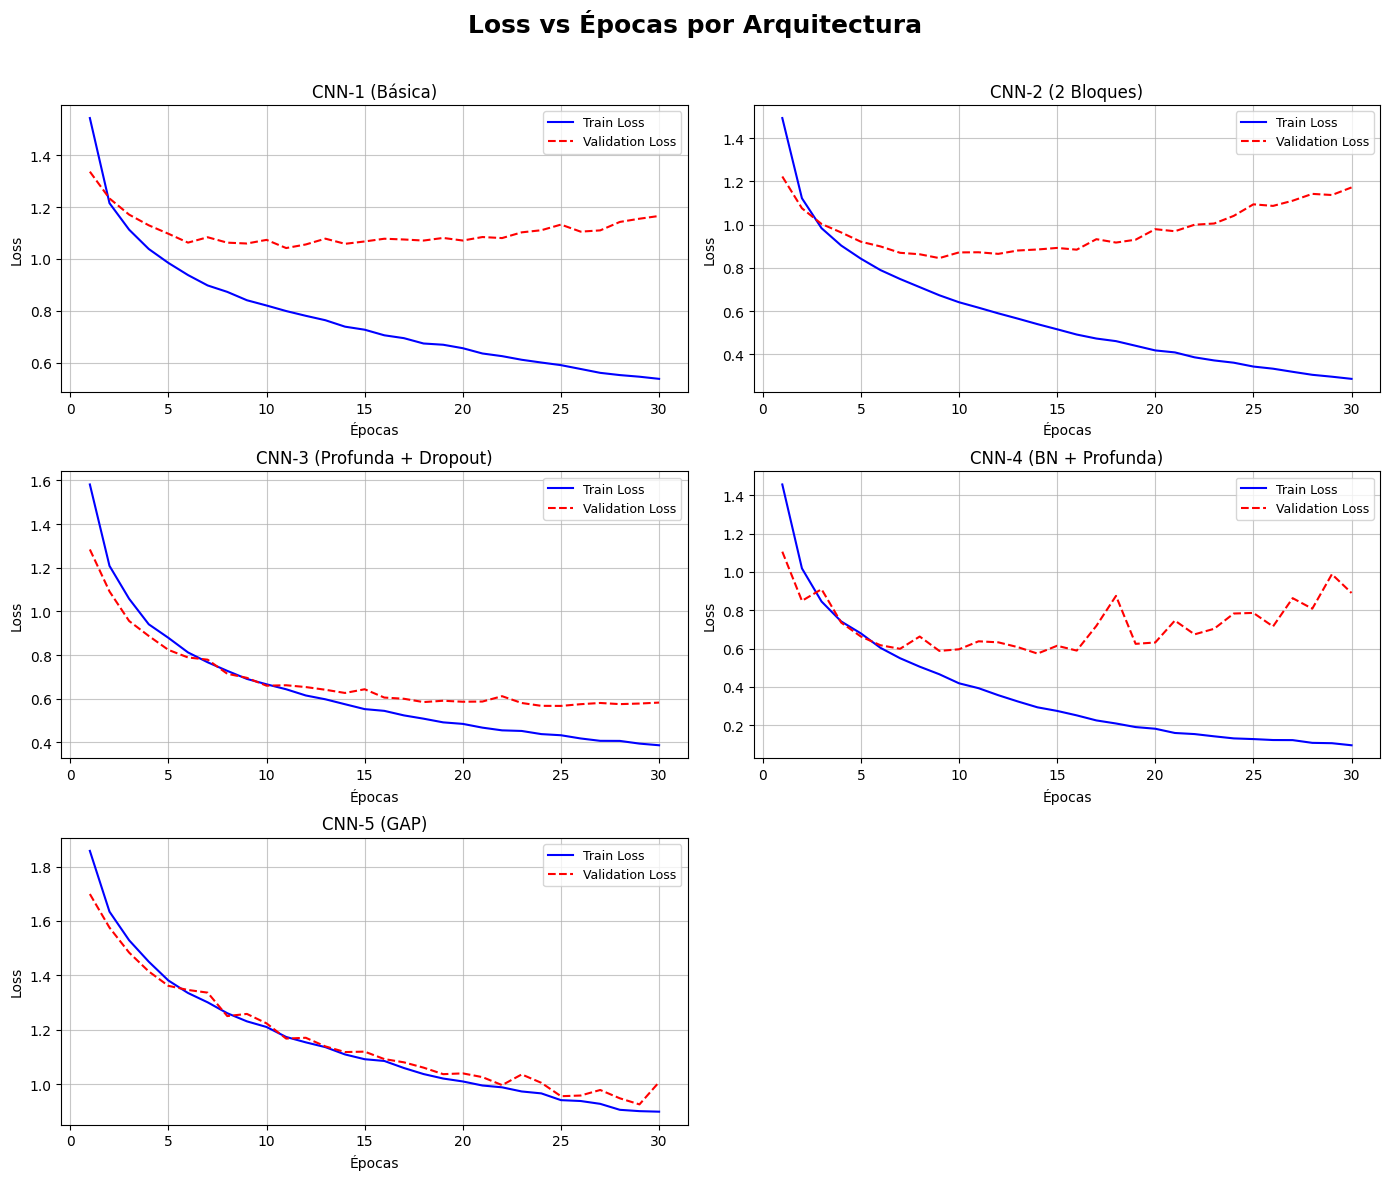

Generando gráficas de Accuracy...


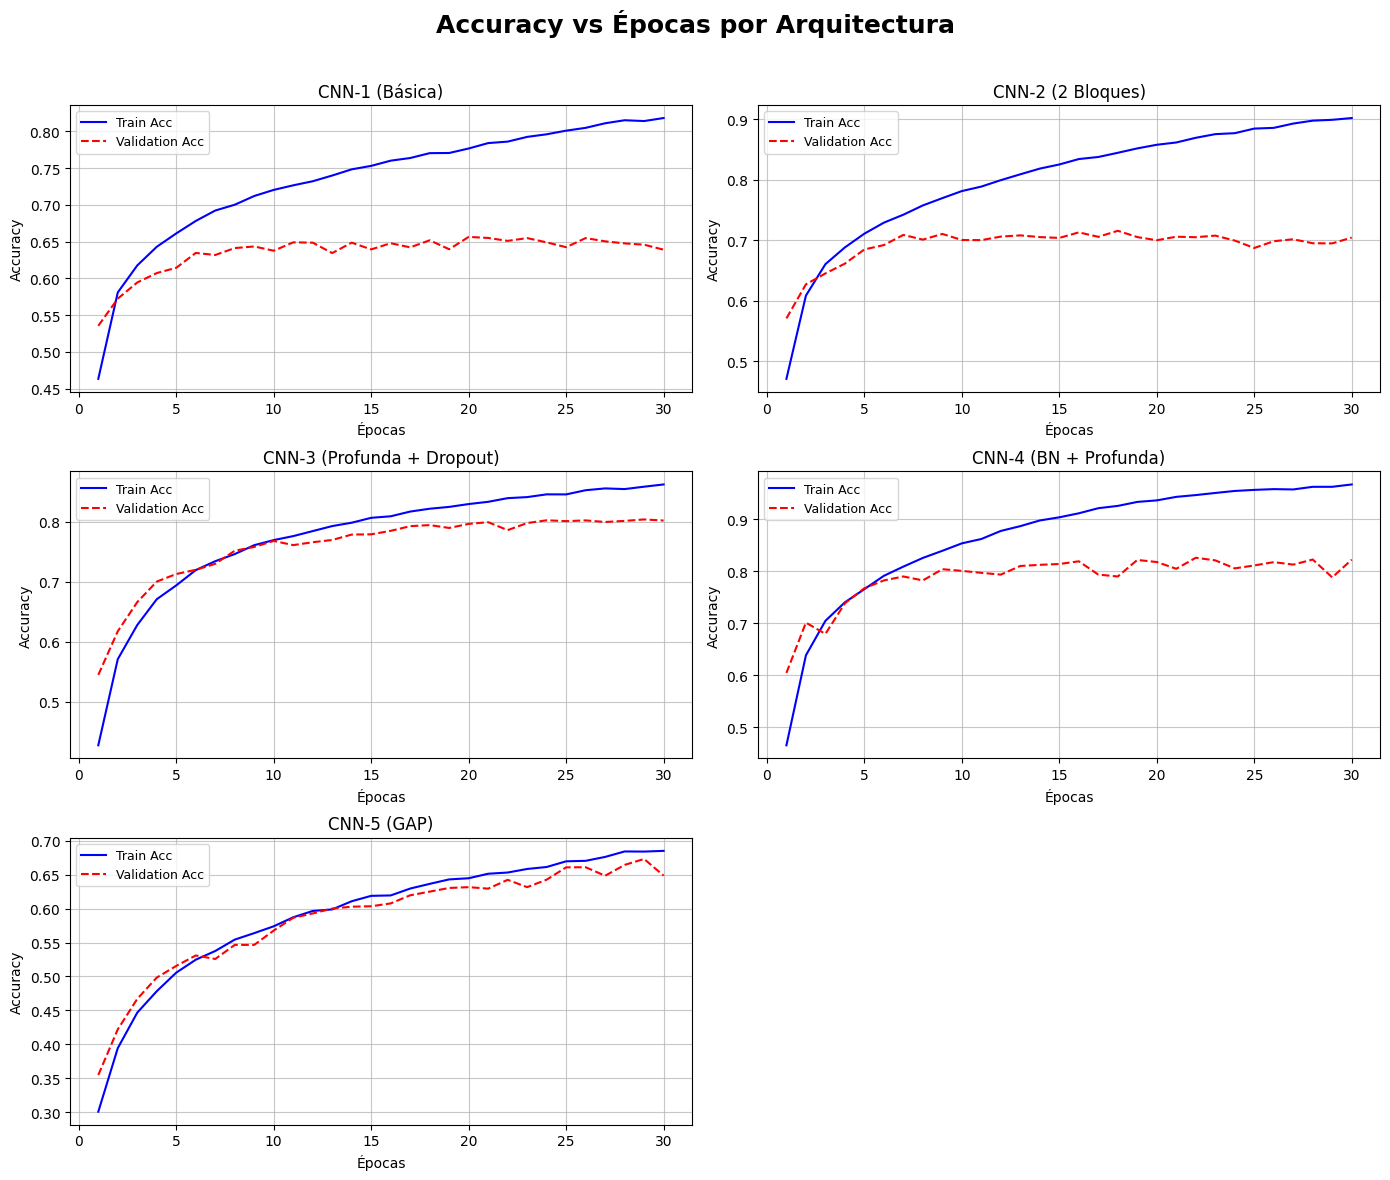


TABLA COMPARATIVA OBLIGATORIA (EVALUACIÓN EN TEST FINAL)
              Arquitectura # Parámetros Train Loss Train Acc Test Loss Test Acc
            CNN-1 (Básica)       82,826     0.5382    81.82%    1.1429   63.61%
         CNN-2 (2 Bloques)       60,362     0.2862    90.19%    1.2039   70.15%
CNN-3 (Profunda + Dropout)      106,538     0.3871    86.20%    0.6060   79.62%
     CNN-4 (BN + Profunda)      667,178     0.0954    96.65%    0.9388   80.69%
               CNN-5 (GAP)      373,386     0.8998    68.53%    1.0174   65.02%


In [17]:

modelos = {
    'CNN-1 (Básica)': CNN1(),
    'CNN-2 (2 Bloques)': CNN2(),
    'CNN-3 (Profunda + Dropout)': CNN3(),
    'CNN-4 (BN + Profunda)': CNN4(),
    'CNN-5 (GAP)': CNN5(),
}

resultados_finales = []
historiales_completos = {}

for nombre, modelo in modelos.items():
    print(f"\n{'='*40}\nIniciando: {nombre}\n{'='*40}")
    
    trainer = EntrenadorModelos(modelo, train_loader, val_loader, test_loader, device=device)
    metricas = trainer.run()
    historiales_completos[nombre] = trainer.history
    
    resultados_finales.append({
        'Arquitectura': nombre,
        '# Parámetros': f"{metricas['Parametros']:,}",
        'Train Loss': f"{metricas['Train Loss']:.4f}",
        'Train Acc': f"{metricas['Train Acc']:.2%}",
        'Test Loss': f"{metricas['Test Loss']:.4f}", 
        'Test Acc': f"{metricas['Test Acc']:.2%}"     
    })

print("\nGenerando gráficas de Loss...")

num_modelos = len(historiales_completos)
cols = 2
rows = math.ceil(num_modelos / cols)
fig_loss, axs_loss = plt.subplots(rows, cols, figsize=(14, 4 * rows))
fig_loss.suptitle('Loss vs Épocas por Arquitectura', fontsize=18, fontweight='bold')
axs_loss = axs_loss.flatten()

for i, (nombre, hist) in enumerate(historiales_completos.items()):
    epocas = range(1, len(hist['train_loss']) + 1)
    axs_loss[i].plot(epocas, hist['train_loss'], 'b-', label='Train Loss', linewidth=1.5)
    axs_loss[i].plot(epocas, hist['val_loss'], 'r--', label='Validation Loss', linewidth=1.5)
    
    axs_loss[i].set_title(nombre, fontsize=12)
    axs_loss[i].set_xlabel('Épocas', fontsize=10)
    axs_loss[i].set_ylabel('Loss', fontsize=10)
    axs_loss[i].legend(fontsize=9)
    axs_loss[i].grid(True, linestyle='-', alpha=0.7)
for j in range(i + 1, len(axs_loss)):
    axs_loss[j].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()
print("Generando gráficas de Accuracy...")
fig_acc, axs_acc = plt.subplots(rows, cols, figsize=(14, 4 * rows))
fig_acc.suptitle('Accuracy vs Épocas por Arquitectura', fontsize=18, fontweight='bold')
axs_acc = axs_acc.flatten()

for i, (nombre, hist) in enumerate(historiales_completos.items()):
    epocas = range(1, len(hist['train_acc']) + 1)
    
    axs_acc[i].plot(epocas, hist['train_acc'], 'b-', label='Train Acc', linewidth=1.5)
    axs_acc[i].plot(epocas, hist['val_acc'], 'r--', label='Validation Acc', linewidth=1.5)
    
    axs_acc[i].set_title(nombre, fontsize=12)
    axs_acc[i].set_xlabel('Épocas', fontsize=10)
    axs_acc[i].set_ylabel('Accuracy', fontsize=10)
    axs_acc[i].legend(fontsize=9)
    axs_acc[i].grid(True, linestyle='-', alpha=0.7)
for j in range(i + 1, len(axs_acc)):
    axs_acc[j].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()
tabla_df = pd.DataFrame(resultados_finales)
print("\n" + "="*80)
print("TABLA COMPARATIVA OBLIGATORIA (EVALUACIÓN EN TEST FINAL)")
print("="*80)
print(tabla_df.to_string(index=False))

   
---

### Instrucción C — CNN propuesta por el estudiante
Propón 1 CNN adicional que mejore a las anteriores (precisión, parámetros, estabilidad, etc.).

### Qué almacenar (para cada modelo: MLP + 6 CNN)
- Loss y accuracy en **entrenamiento**
- Loss y accuracy en **prueba**

### Tabla obligatoria
Comparar todos los modelos con:
- Resumen arquitectura
- **# parámetros entrenables**
- Loss/Acc train
- Loss/Acc test


In [18]:
class CNN6_Mejorada(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # BLOQUE 1: Detecta texturas simples (32x32)
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # -> 16x16
            nn.Dropout2d(0.2),

            # BLOQUE 2: Detecta formas (16x16)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # -> 8x8
            nn.Dropout2d(0.3),

            # BLOQUE 3: Detecta objetos complejos (8x8)
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # -> 4x4
            nn.Dropout2d(0.4),

            # Decisión final
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 10)
        )

    def forward(self, x):
        return self.net(x)

In [19]:

transform_train_aug = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(cifar10_mean, cifar10_std) 
])

dataset_train_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train_aug)

train_set_aug = Subset(dataset_train_aug, perm[:n_train]) 

train_loader = DataLoader(train_set_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Data Augmentation")

Data Augmentation



Iniciando: CNN-6 (Propuesta)

Entrenando modelo con 1,187,274 parámetros...
Epoch [1/30] | Train Loss: 1.7844 | Val Loss: 1.4436 | Val Acc: 0.4564
Epoch [5/30] | Train Loss: 1.0398 | Val Loss: 0.7754 | Val Acc: 0.7224
Epoch [10/30] | Train Loss: 0.8060 | Val Loss: 0.6059 | Val Acc: 0.7886
Epoch [15/30] | Train Loss: 0.6951 | Val Loss: 0.5174 | Val Acc: 0.8186
Epoch [20/30] | Train Loss: 0.6272 | Val Loss: 0.4590 | Val Acc: 0.8388
Epoch [25/30] | Train Loss: 0.5757 | Val Loss: 0.4465 | Val Acc: 0.8472
Epoch [30/30] | Train Loss: 0.5335 | Val Loss: 0.4134 | Val Acc: 0.8560
Realizando evaluación final en el conjunto de Test...

Generando gráficas de Loss actualizadas...


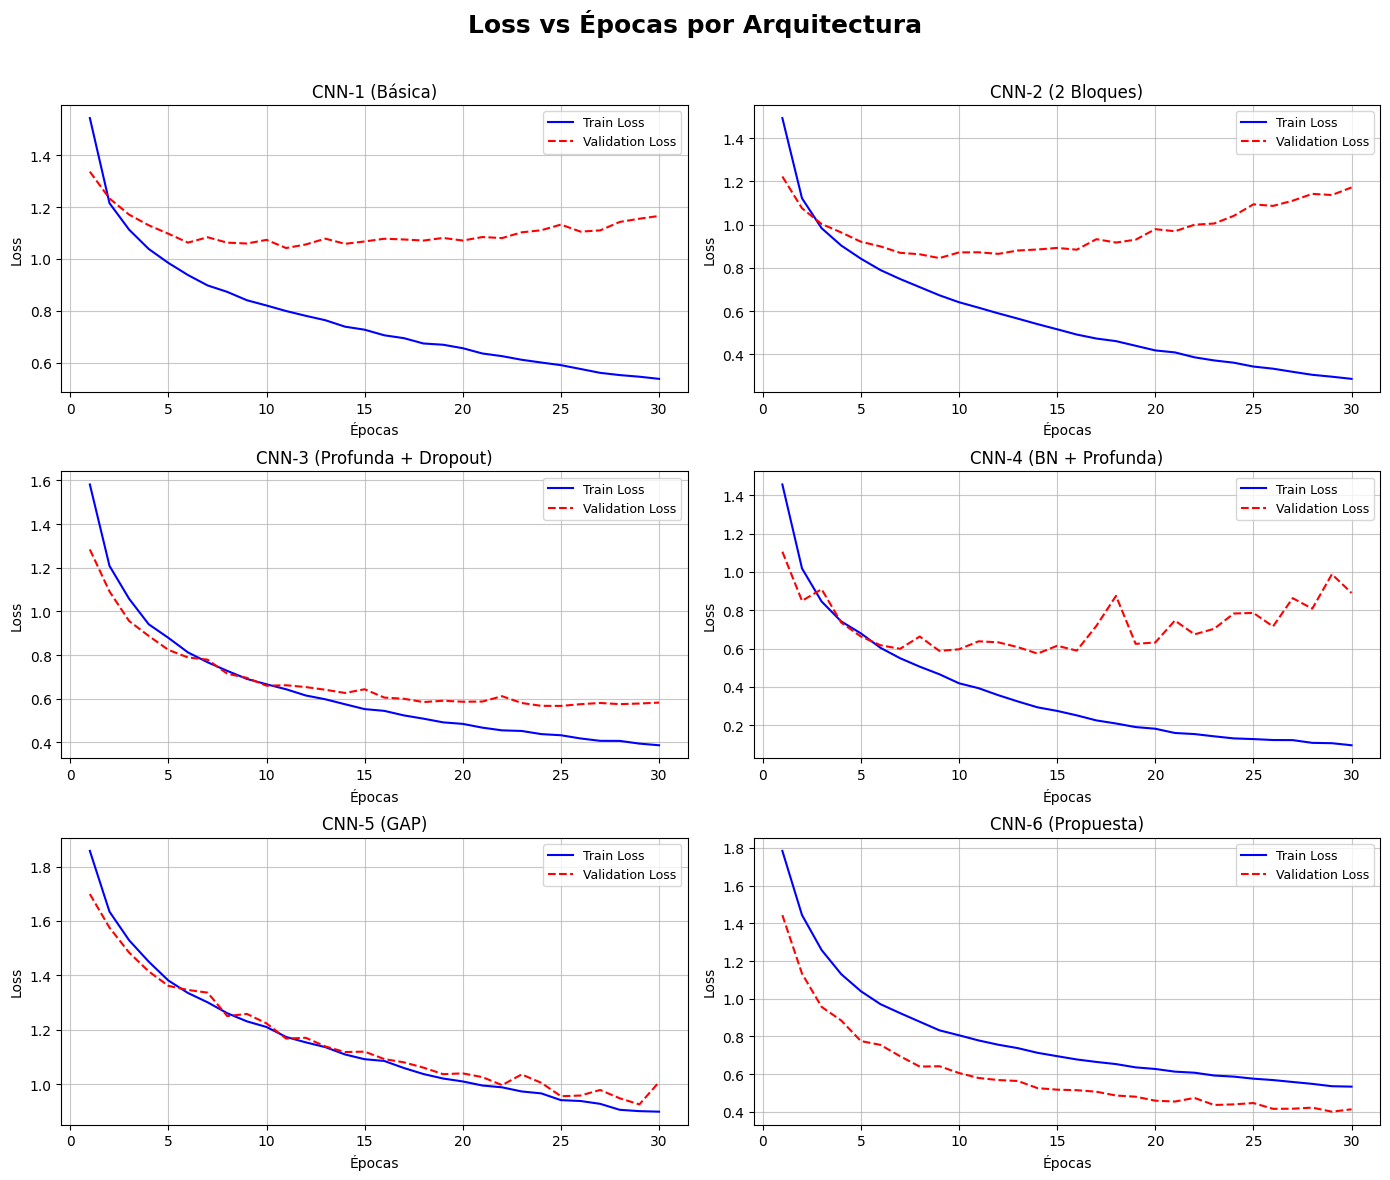

Generando gráficas de Accuracy actualizadas...


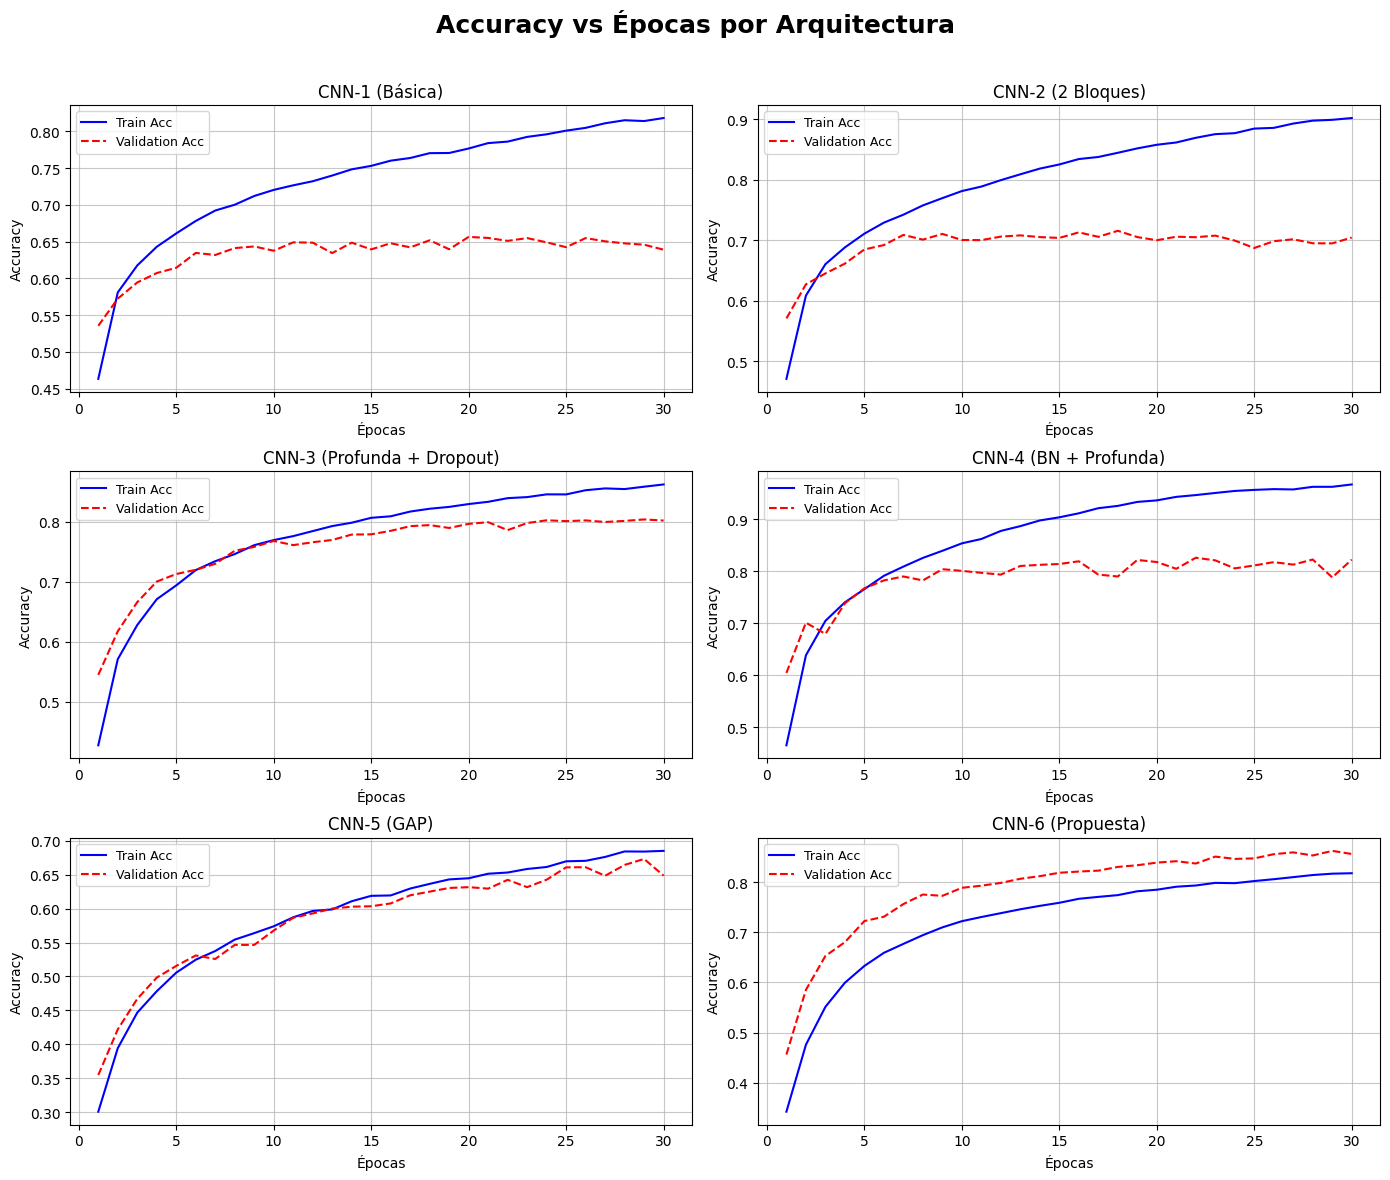


TABLA COMPARATIVA OBLIGATORIA (EVALUACIÓN EN TEST FINAL)
              Arquitectura # Parámetros Train Loss Train Acc Test Loss Test Acc
            CNN-1 (Básica)       82,826     0.5382    81.82%    1.1429   63.61%
         CNN-2 (2 Bloques)       60,362     0.2862    90.19%    1.2039   70.15%
CNN-3 (Profunda + Dropout)      106,538     0.3871    86.20%    0.6060   79.62%
     CNN-4 (BN + Profunda)      667,178     0.0954    96.65%    0.9388   80.69%
               CNN-5 (GAP)      373,386     0.8998    68.53%    1.0174   65.02%
         CNN-6 (Propuesta)    1,187,274     0.5335    81.76%    0.4378   85.25%


In [20]:
nombre_nueva = 'CNN-6 (Propuesta)'
modelo_nuevo = CNN6_Mejorada() # Reemplaza por el nombre real de tu clase

print(f"\n{'='*40}\nIniciando: {nombre_nueva}\n{'='*40}")
trainer = EntrenadorModelos(modelo_nuevo, train_loader, val_loader, test_loader, device=device)
metricas = trainer.run()

# 2. LO MÁS IMPORTANTE: Agregar a la memoria existente (NO uses "=" vacío)
historiales_completos[nombre_nueva] = trainer.history
resultados_finales.append({
    'Arquitectura': nombre_nueva,
    '# Parámetros': f"{metricas['Parametros']:,}",
    'Train Loss': f"{metricas['Train Loss']:.4f}",
    'Train Acc': f"{metricas['Train Acc']:.2%}",
    'Test Loss': f"{metricas['Test Loss']:.4f}", 
    'Test Acc': f"{metricas['Test Acc']:.2%}"    
})

# =========================================================
# 3. A PARTIR DE AQUÍ, SÍ COPIAS Y PEGAS EL CÓDIGO DE GRÁFICAS
# =========================================================
print("\nGenerando gráficas de Loss actualizadas...")

num_modelos = len(historiales_completos) # Ahora detectará 6 en lugar de 5
cols = 2
rows = math.ceil(num_modelos / cols)

# ... (Pega aquí el resto de tu código para graficar Loss) ...
fig_loss, axs_loss = plt.subplots(rows, cols, figsize=(14, 4 * rows))
fig_loss.suptitle('Loss vs Épocas por Arquitectura', fontsize=18, fontweight='bold')
axs_loss = axs_loss.flatten()

for i, (nombre, hist) in enumerate(historiales_completos.items()):
    epocas = range(1, len(hist['train_loss']) + 1)
    axs_loss[i].plot(epocas, hist['train_loss'], 'b-', label='Train Loss', linewidth=1.5)
    axs_loss[i].plot(epocas, hist['val_loss'], 'r--', label='Validation Loss', linewidth=1.5)
    
    axs_loss[i].set_title(nombre, fontsize=12)
    axs_loss[i].set_xlabel('Épocas', fontsize=10)
    axs_loss[i].set_ylabel('Loss', fontsize=10)
    axs_loss[i].legend(fontsize=9)
    axs_loss[i].grid(True, linestyle='-', alpha=0.7)

for j in range(i + 1, len(axs_loss)):
    axs_loss[j].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# ... (Pega aquí el código para graficar Accuracy) ...
print("Generando gráficas de Accuracy actualizadas...")
fig_acc, axs_acc = plt.subplots(rows, cols, figsize=(14, 4 * rows))
fig_acc.suptitle('Accuracy vs Épocas por Arquitectura', fontsize=18, fontweight='bold')
axs_acc = axs_acc.flatten()

for i, (nombre, hist) in enumerate(historiales_completos.items()):
    epocas = range(1, len(hist['train_acc']) + 1)
    
    axs_acc[i].plot(epocas, hist['train_acc'], 'b-', label='Train Acc', linewidth=1.5)
    axs_acc[i].plot(epocas, hist['val_acc'], 'r--', label='Validation Acc', linewidth=1.5)
    
    axs_acc[i].set_title(nombre, fontsize=12)
    axs_acc[i].set_xlabel('Épocas', fontsize=10)
    axs_acc[i].set_ylabel('Accuracy', fontsize=10)
    axs_acc[i].legend(fontsize=9)
    axs_acc[i].grid(True, linestyle='-', alpha=0.7)

for j in range(i + 1, len(axs_acc)):
    axs_acc[j].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.show()

# Imprimir la tabla actualizada
tabla_df = pd.DataFrame(resultados_finales)
print("\n" + "="*80)
print("TABLA COMPARATIVA OBLIGATORIA (EVALUACIÓN EN TEST FINAL)")
print("="*80)
print(tabla_df.to_string(index=False))

## 8. Interpretabilidad: filtros y mapas de activación 

Para cada CNN:
1. Visualiza algunos filtros de la primera capa (p.ej. 16 filtros).
2. Analiza mapas de activación para 2–3 imágenes en:
   - Primera capa/bloque
   - Un bloque intermedio
   - Última capa antes del clasificador

Incluye un análisis: qué detectan, cómo evoluciona la abstracción, etc.



 Visualizando: CNN-1


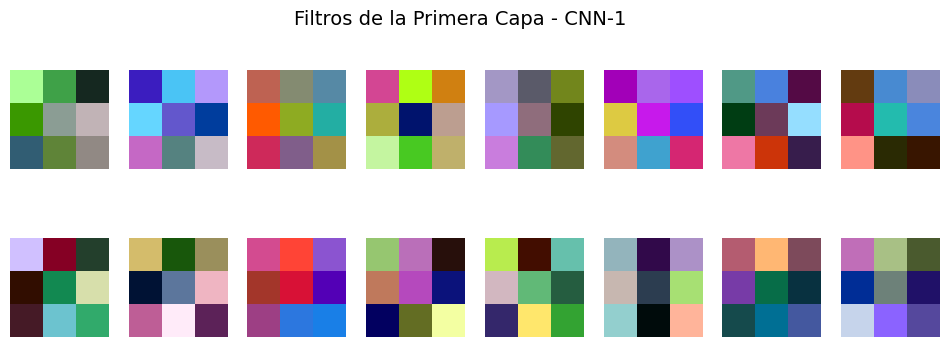

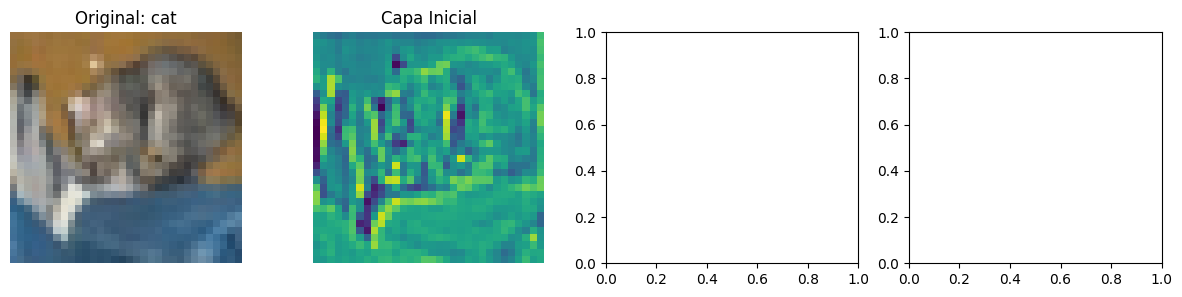

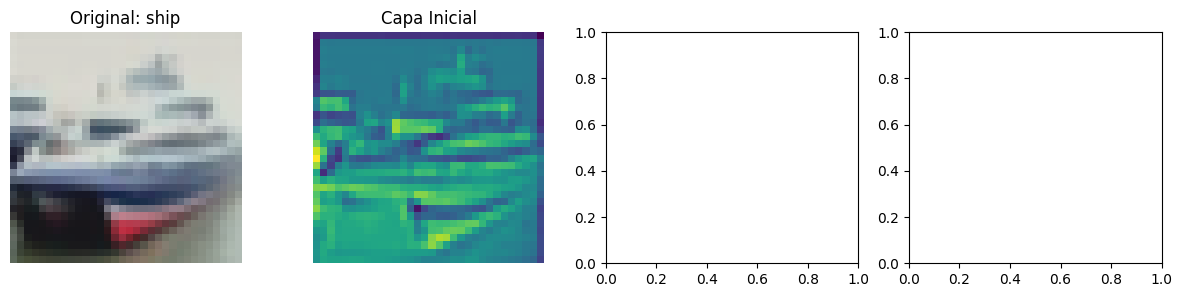

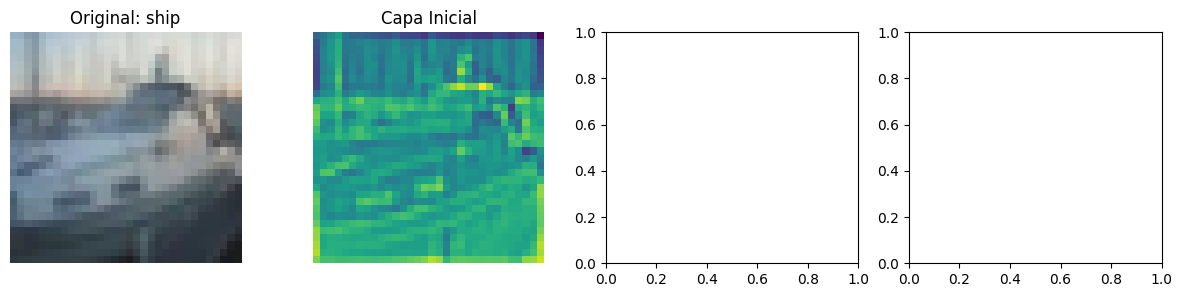


 Visualizando: CNN-2


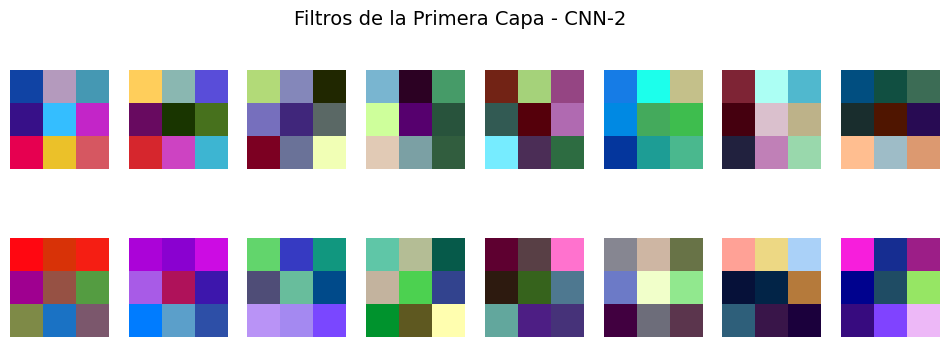

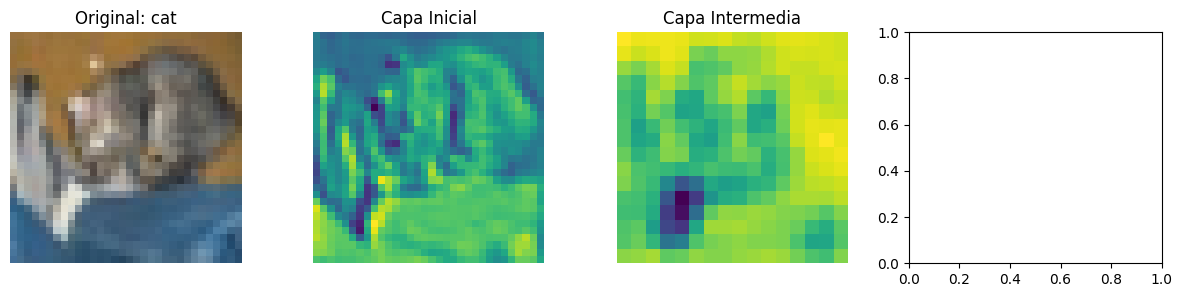

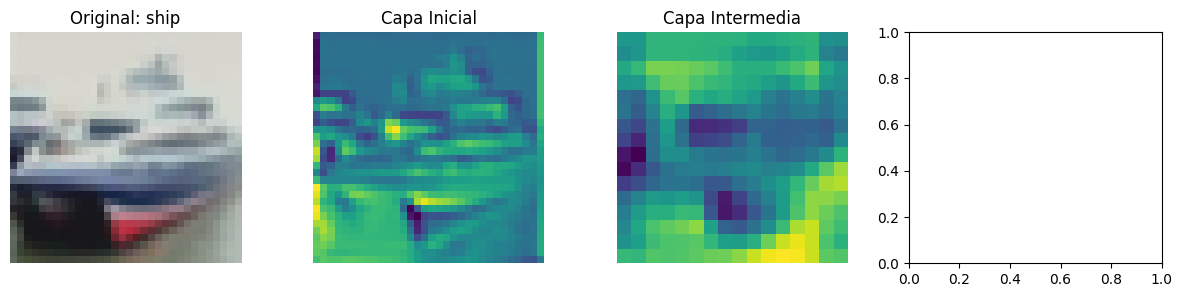

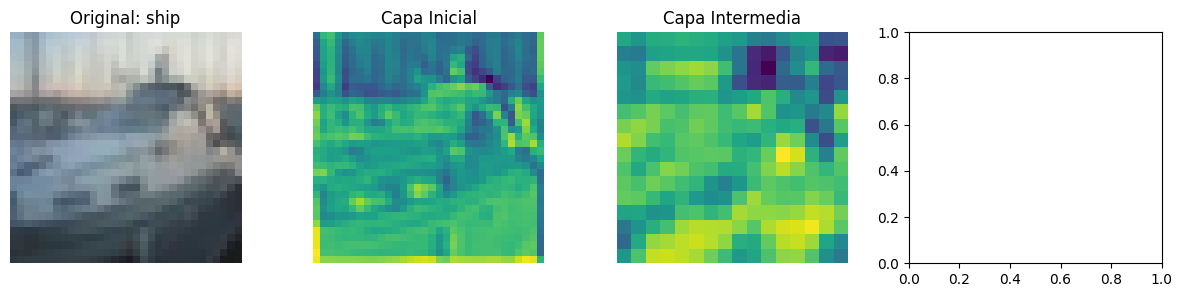


 Visualizando: CNN-3


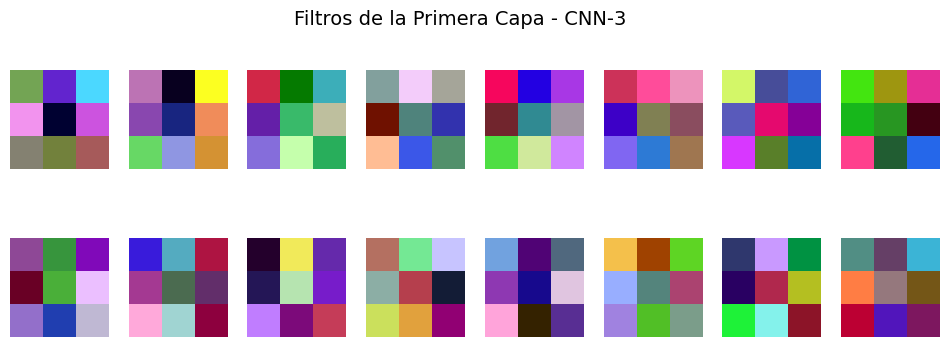

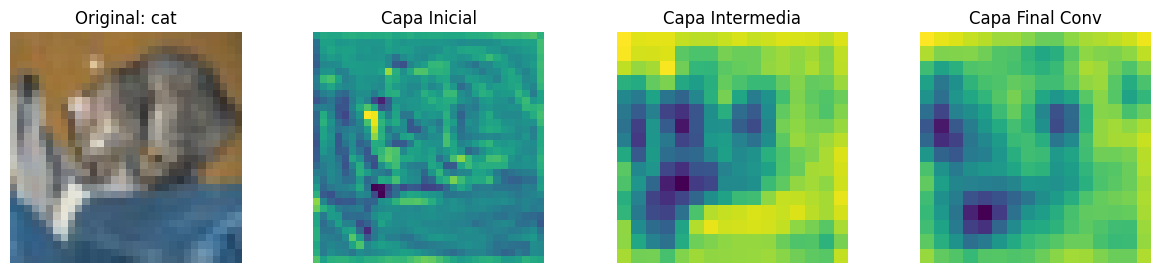

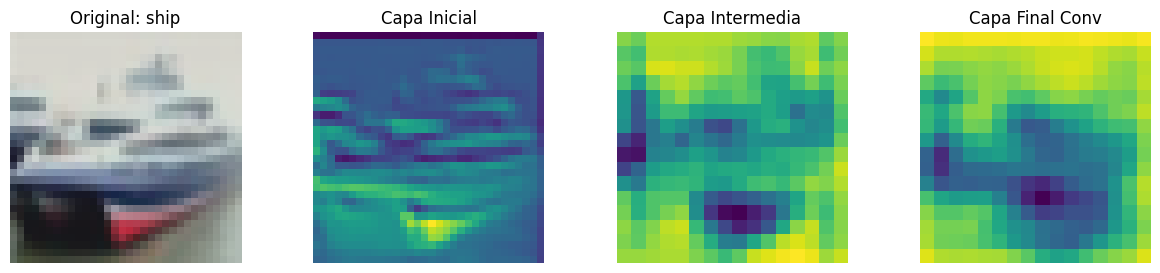

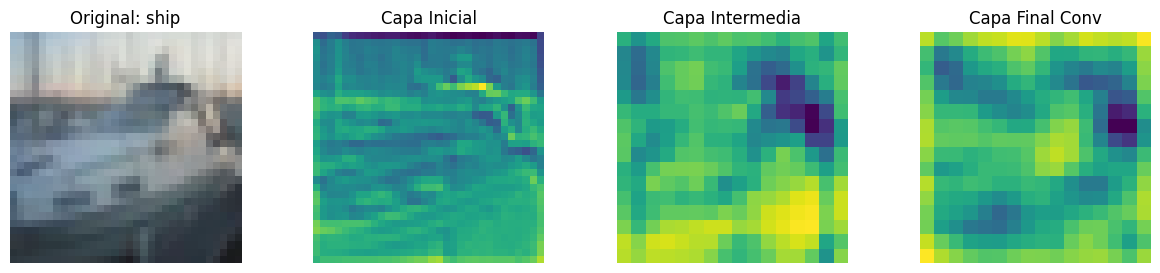


 Visualizando: CNN-4


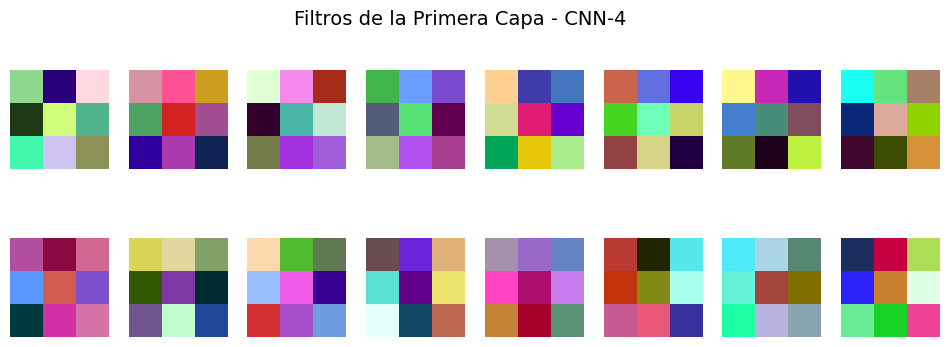

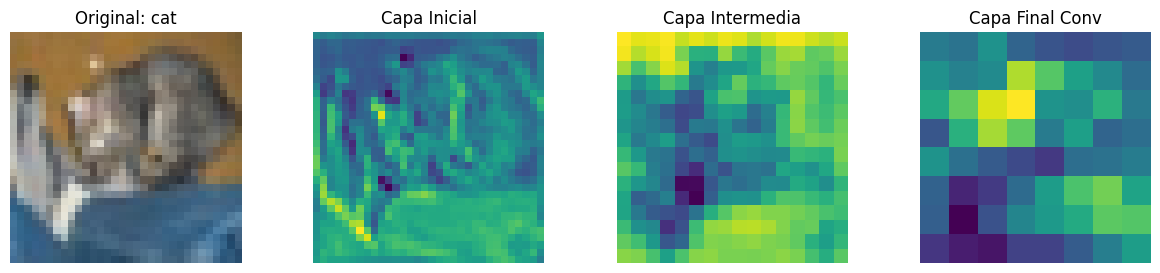

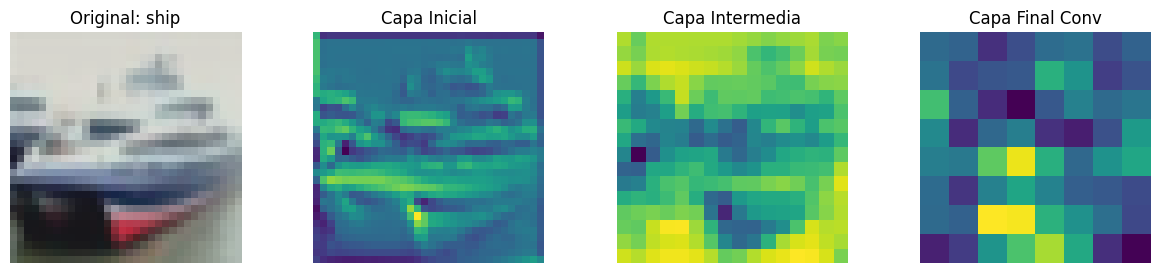

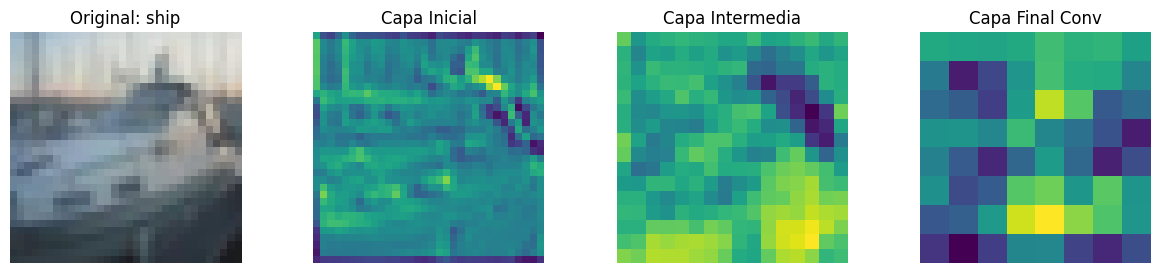


 Visualizando: CNN-5


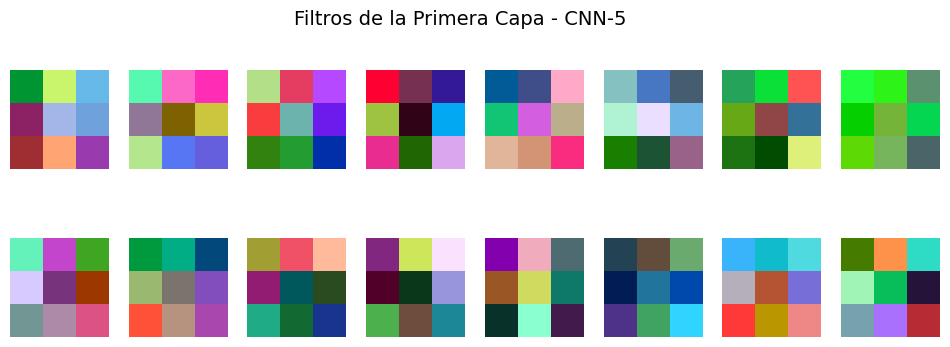

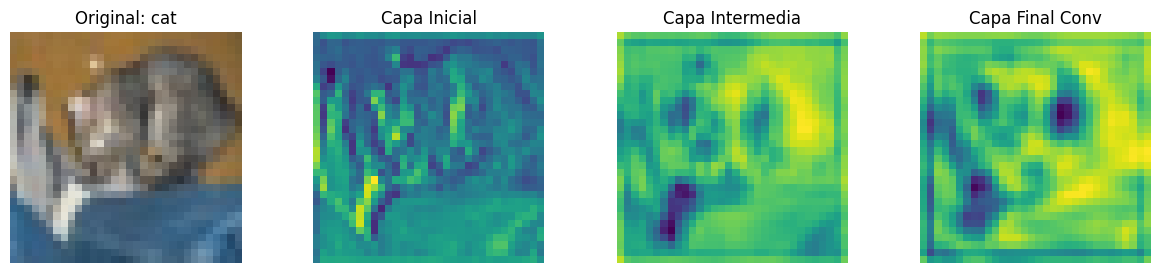

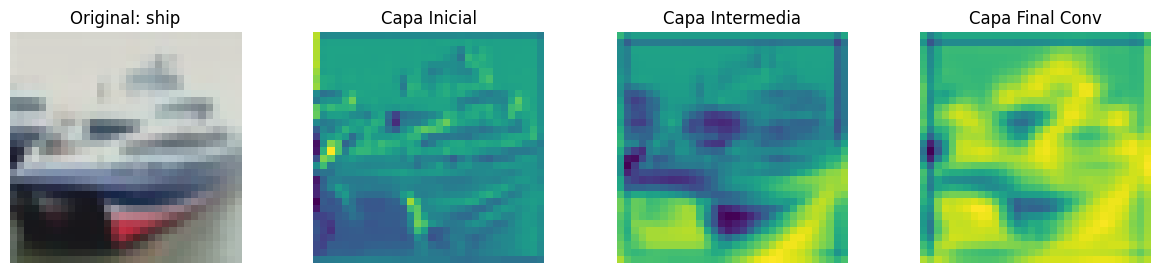

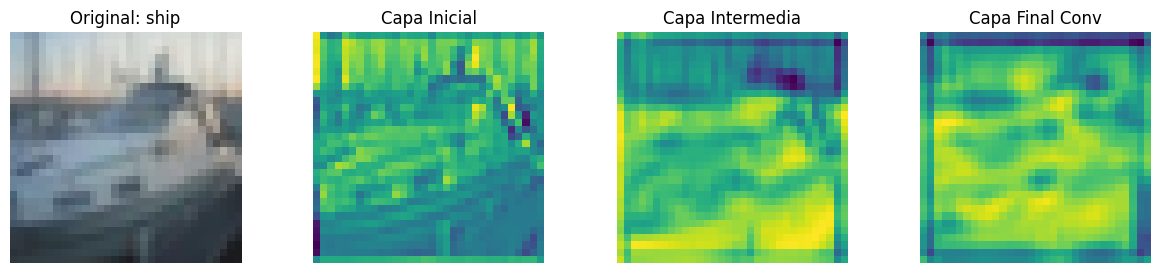


 Visualizando: CNN-6


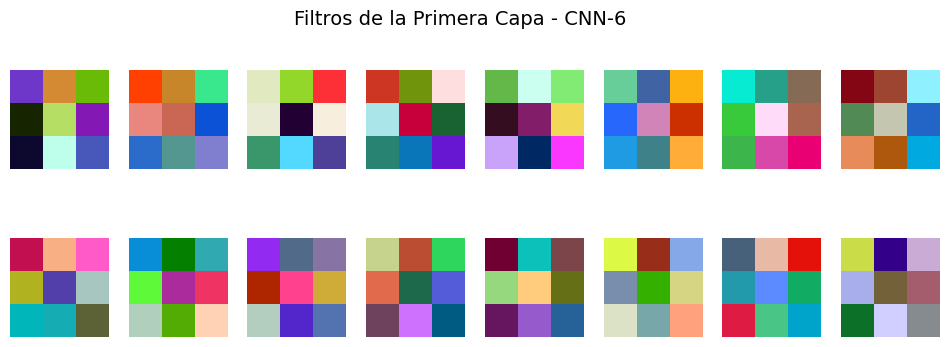

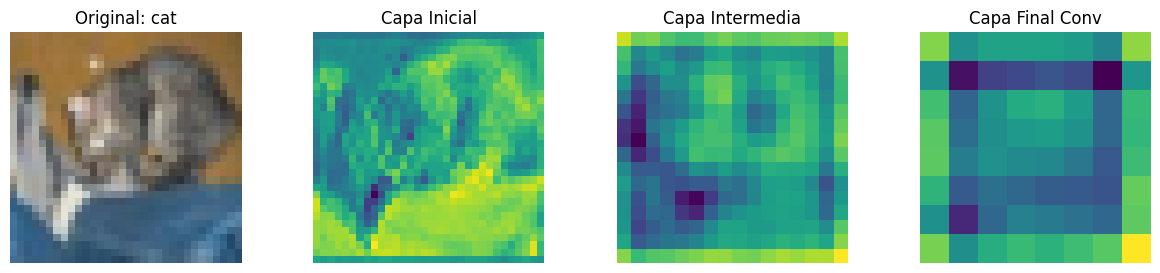

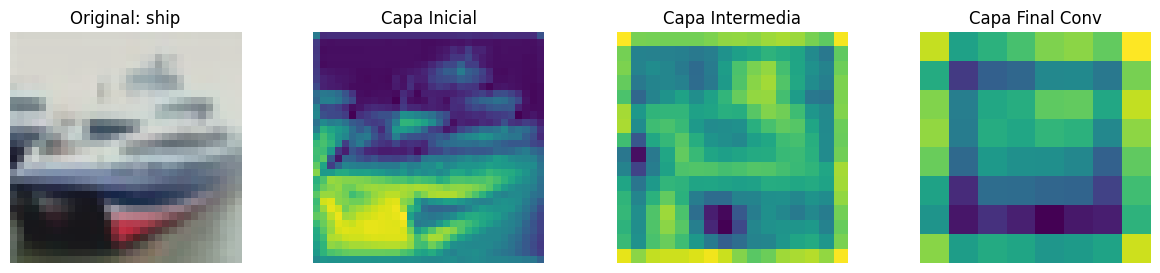

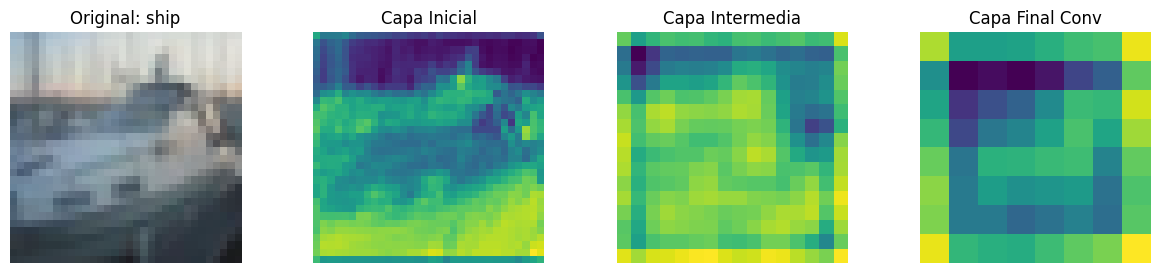

In [21]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# 1. Seleccionar 3 imágenes aleatorias del set de test al inicio
# Usamos el test_loader que ya definiste en tu notebook
dataiter = iter(test_loader)
images, labels = next(dataiter)
indices = [0, 1, 2] # Elegimos las 3 primeras del batch para consistencia
img_samples = images[indices].to(device)
clases = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

def desnormalizar(img):
    img = img.cpu().numpy().transpose((1, 2, 0))
    # Valores de media y std de CIFAR-10 que usaste
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = std * img + mean
    return np.clip(img, 0, 1)

# Diccionario con TODOS tus modelos para iterar
mis_modelos = {
    'CNN-1': modelos['CNN-1 (Básica)'],
    'CNN-2': modelos['CNN-2 (2 Bloques)'],
    'CNN-3': modelos['CNN-3 (Profunda + Dropout)'],
    'CNN-4': modelos['CNN-4 (BN + Profunda)'],
    'CNN-5': modelos['CNN-5 (GAP)'],
    'CNN-6': modelo_nuevo # Tu propuesta mejorada
}

for nombre, mod in mis_modelos.items():
    mod.eval()
    print(f"\n Visualizando: {nombre}")
    
    # --- PARTE 1: Visualizar Filtros (Primera Capa) ---
    # En tus modelos, la primera capa siempre es mod.net[0]
    filtros = mod.net[0].weight.data.cpu()
    
    fig, axs = plt.subplots(2, 8, figsize=(12, 4))
    fig.suptitle(f'Filtros de la Primera Capa - {nombre}', fontsize=14)
    for i in range(16):
        f = filtros[i]
        f = (f - f.min()) / (f.max() - f.min()) # Normalizar para plot
        axs[i//8, i%8].imshow(f.permute(1, 2, 0))
        axs[i//8, i%8].axis('off')
    plt.show()

    # --- PARTE 2: Mapas de Activación ---
    # Identificamos los índices de las capas según tus arquitecturas
    # Primera, intermedia (aprox) y última conv antes del Flatten/GAP
    conv_indices = [i for i, layer in enumerate(mod.net) if isinstance(layer, torch.nn.Conv2d)]
    layers_to_show = [conv_indices[0], conv_indices[len(conv_indices)//2], conv_indices[-1]]

    for i in range(3): # Para cada una de las 3 imágenes
        img_input = img_samples[i].unsqueeze(0)
        activaciones = []
        
        # Hook manual: pasar la imagen por la red y guardar salidas
        x = img_input
        for idx, layer in enumerate(mod.net):
            x = layer(x)
            if idx in layers_to_show:
                activaciones.append(x.detach().cpu())
            if isinstance(layer, (torch.nn.Flatten, torch.nn.AdaptiveAvgPool2d)):
                break
        
        # Plotear
        fig, axs = plt.subplots(1, 4, figsize=(15, 3))
        axs[0].imshow(desnormalizar(img_samples[i]))
        axs[0].set_title(f"Original: {clases[labels[i]]}")
        axs[0].axis('off')
        
        titulos = ['Capa Inicial', 'Capa Intermedia', 'Capa Final Conv']
        for j, act in enumerate(activaciones):
            # Promediamos canales para ver el mapa de calor
            mapa = torch.mean(act[0], dim=0)
            axs[j+1].imshow(mapa, cmap='viridis')
            axs[j+1].set_title(titulos[j])
            axs[j+1].axis('off')
        plt.show()

## 9. Experimento: permutación fija de píxeles

Aplicaremos una permutación fija a los 3072 valores (C×H×W aplanado), y construiremos:
- Dataset permutado ORIGINAL (para CNN)
- Dataset permutado FLAT (para MLP)

Mantendremos la misma partición .


In [32]:
# Permutación fija (reproducible)
perm_seed = 123
g_perm = torch.Generator().manual_seed(perm_seed)
pixel_perm = torch.randperm(3*32*32, generator=g_perm)

pixel_perm.shape, pixel_perm[:10]


(torch.Size([3072]),
 tensor([1534, 1122, 1264, 1074, 2552, 2280,  960,  899, 2683, 1750]))

In [33]:
def permute_image_tensor(x, pixel_perm):
    # x: (3,32,32) -> flatten(3072) -> permute -> reshape(3,32,32)
    x_flat = torch.flatten(x, start_dim=0)
    x_perm = x_flat[pixel_perm]
    return x_perm.view(3, 32, 32)

# sanity check
x, y = train_full[0]
x_p = permute_image_tensor(x, pixel_perm)
print("Original:", x.shape, "Perm:", x_p.shape, "label:", y)


Original: torch.Size([3, 32, 32]) Perm: torch.Size([3, 32, 32]) label: 6


### Wrappers permutados


In [34]:
class PermutedWrapper(torch.utils.data.Dataset):
    def __init__(self, base_dataset, pixel_perm):
        self.base = base_dataset
        self.pixel_perm = pixel_perm

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        x = permute_image_tensor(x, self.pixel_perm)
        return x, y

class PermutedFlatWrapper(torch.utils.data.Dataset):
    def __init__(self, base_dataset, pixel_perm):
        self.base = base_dataset
        self.pixel_perm = pixel_perm

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        x, y = self.base[idx]
        x = permute_image_tensor(x, self.pixel_perm)
        x = torch.flatten(x, start_dim=0)
        return x, y

perm_train_full = PermutedWrapper(train_full, pixel_perm)
perm_test_set   = PermutedWrapper(test_set, pixel_perm)

perm_flat_train_full = PermutedFlatWrapper(train_full, pixel_perm)
perm_flat_test_set   = PermutedFlatWrapper(test_set, pixel_perm)

xp, yp = perm_train_full[0]
xpf, ypf = perm_flat_train_full[0]
print("Perm original sample:", xp.shape, yp)
print("Perm flat sample:", xpf.shape, ypf)


Perm original sample: torch.Size([3, 32, 32]) 6
Perm flat sample: torch.Size([3072]) 6


In [35]:
#    - num_workers=0 evita deadlocks por multiprocessing
#    - pin_memory solo si estás usando CUDA
use_cuda = torch.cuda.is_available()
PIN_MEMORY = True if use_cuda else False
NUM_WORKERS = 0   # <- lo más seguro en notebooks

# (Opcional) Para mayor reproducibilidad de la carga
g_loader = torch.Generator().manual_seed(SEED)

perm_test_loader = DataLoader(
    perm_test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

perm_flat_test_loader = DataLoader(
    perm_flat_test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# 3) Prueba de batch (sin colgarse)
xb, yb = next(iter(perm_test_loader))
xfb, yfb = next(iter(perm_flat_test_loader))

print("Perm batch original:", xb.shape, yb.shape)
print("Perm batch flat:", xfb.shape, yfb.shape)


Perm batch original: torch.Size([256, 3, 32, 32]) torch.Size([256])
Perm batch flat: torch.Size([256, 3072]) torch.Size([256])


## 10. Usando datos permutados

- Muestra 2 imagenes de cada clase con los datos permutados
- Con las dos topologías propuestas (FCFFNN y CNN) prueba con los datos permutados. Argumenta tus resultados
- Entrega una tabla comparando (normal vs permutado) y explica por qué la CNN se afecta más.

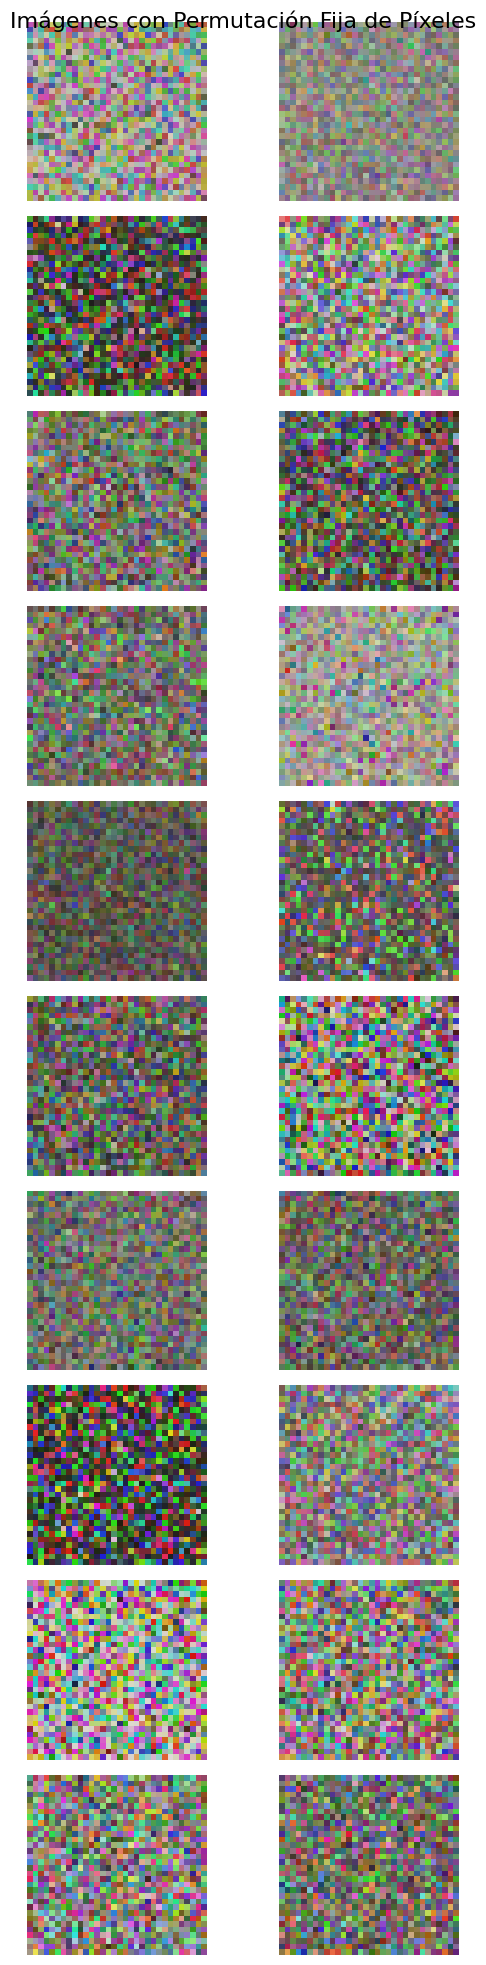

In [38]:
import matplotlib.pyplot as plt
import numpy as np

def imshow_perm(img):
    img = img.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2023, 0.1994, 0.2010])
    img = std * img + mean
    plt.imshow(np.clip(img, 0, 1))

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# Diccionario para guardar 2 índices por clase
indices_por_clase = {i: [] for i in range(10)}
for idx in range(len(test_set)):
    _, label = test_set[idx]
    if len(indices_por_clase[label]) < 2:
        indices_por_clase[label].append(idx)
    if all(len(v) == 2 for v in indices_por_clase.values()):
        break

fig = plt.subplots(10, 2, figsize=(6, 20))
plt.suptitle("Imágenes con Permutación Fija de Píxeles", fontsize=16)

for label in range(10):
    for i, idx in enumerate(indices_por_clase[label]):
        img_p, _ = perm_test_set[idx]
        plt.subplot(10, 2, label*2 + i + 1)
        imshow_perm(img_p)
        plt.axis('off')
        if i == 0: plt.ylabel(classes[label], rotation=0, labelpad=40, fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
def evaluar_modelo(model, loader, is_mlp=False):
    model.eval()
    correctos = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Si el modelo es MLP y los datos vienen como imagen (C,H,W), aplanamos
            if is_mlp and len(inputs.shape) > 2:
                inputs = inputs.view(inputs.size(0), -1)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correctos += (preds == labels).sum().item()
    return 100 * correctos / total

# 1. Evaluación con Datos Normales
acc_cnn_norm = evaluar_modelo(modelo_nuevo, test_loader)
acc_mlp_norm = evaluar_modelo(model_opt, flat_test_loader, is_mlp=True)

# 2. Evaluación con Datos Permutados
acc_cnn_perm = evaluar_modelo(modelo_nuevo, perm_test_loader)
acc_mlp_perm = evaluar_modelo(model_opt, perm_flat_test_loader, is_mlp=True)

print(f"\nRESULTADOS FINALES")
print(f"{'='*30}")
print(f"CNN-6 (Normal):    {acc_cnn_norm:.2f}% | (Permutado): {acc_cnn_perm:.2f}%")
print(f"MLP (Normal):      {acc_mlp_norm:.2f}% | (Permutado): {acc_mlp_perm:.2f}%")


RESULTADOS FINALES
CNN-6 (Normal):    85.25% | (Permutado): 10.48%
MLP (Normal):      54.34% | (Permutado): 11.35%


: 